<a href="https://colab.research.google.com/github/Giorgosman13/RL_Assignment2/blob/main/Assignment_2_Reverse_Engineering_Non_Stationarity_and_Price_Wars!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

n_arms = 2
arms = [0,1]

In [2]:
class Environment:
  def __init__(self,p_L,p_H,t_L,t_H,initial_states):
    self.count = [0,0]
    self.p_l = p_L
    self.p_h = p_H
    self.t_l = t_L
    self.t_h = t_H
    self.initial_states = initial_states

  def step (self,arm):
    # 1. Determine reward for the chosen arm BEFORE updating states
    current_state = self.initial_states[arm]
    p_a = self.p_l[arm] if current_state == "Low" else self.p_h[arm]
    r = np.random.binomial(1, p_a)

    # 2. Update the internal state of ALL arms (Independent Evolution)
    for i in range(2):
      self.count[i] += 1
      limit = self.t_l[i] if self.initial_states[i] == "Low" else self.t_h[i]

      if self.count[i] >= limit:
        # Toggle state: Low -> High or High -> Low
        self.initial_states[i] = "High" if self.initial_states[i] == "Low" else "Low"
        self.count[i] = 0
    return r


In [3]:
def run_ExploreThenExploit(T,env):
  N = np.power(T/n_arms,2/3).astype(int)

  r_in = np.zeros(n_arms)
  rewards = np.zeros(T)

  arm_selected = np.zeros(n_arms)

  for t in range(T):
    if t <= N:
      arm_i = t % n_arms
    else:
      arm_i = np.argmax(r_in)

    r = env.step(arm_i)
    r_in[arm_i] += r

    arm_selected[arm_i] += 1
    if t == 0:
      rewards[t] = r
    else:
      rewards[t] = r + rewards[t-1]

  return rewards, arm_selected


In [4]:
def run_UCB(T, env):
  reward = np.zeros(T)
  arm_selected = np.zeros(n_arms)

  Xin = np.zeros(n_arms)
  rin = np.zeros(n_arms)
  mu_hat = np.zeros(n_arms)

  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    r = env.step(arm_i)
    #What our algorithm has access to:
    rin[arm_i] += r
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    arm_selected[arm_i] += 1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward,arm_selected

In [5]:
def run_MWbandit(T, env):
  weights = np.ones(n_arms)
  ita = np.sqrt(np.log(n_arms)/T)

  reward = np.zeros(T)
  arm_selected = np.zeros(n_arms)

  for t in range(T):

    weights_sum = np.sum(weights)
    pi = weights / weights_sum

    arm_i = np.random.choice(n_arms,p = pi)

    r = env.step(arm_i)

    l = 1 - r

    est_loss = l / pi[arm_i]

    weights[arm_i] *= np.exp(-ita * est_loss)

    arm_selected[arm_i] +=1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward , arm_selected

# Task A.1

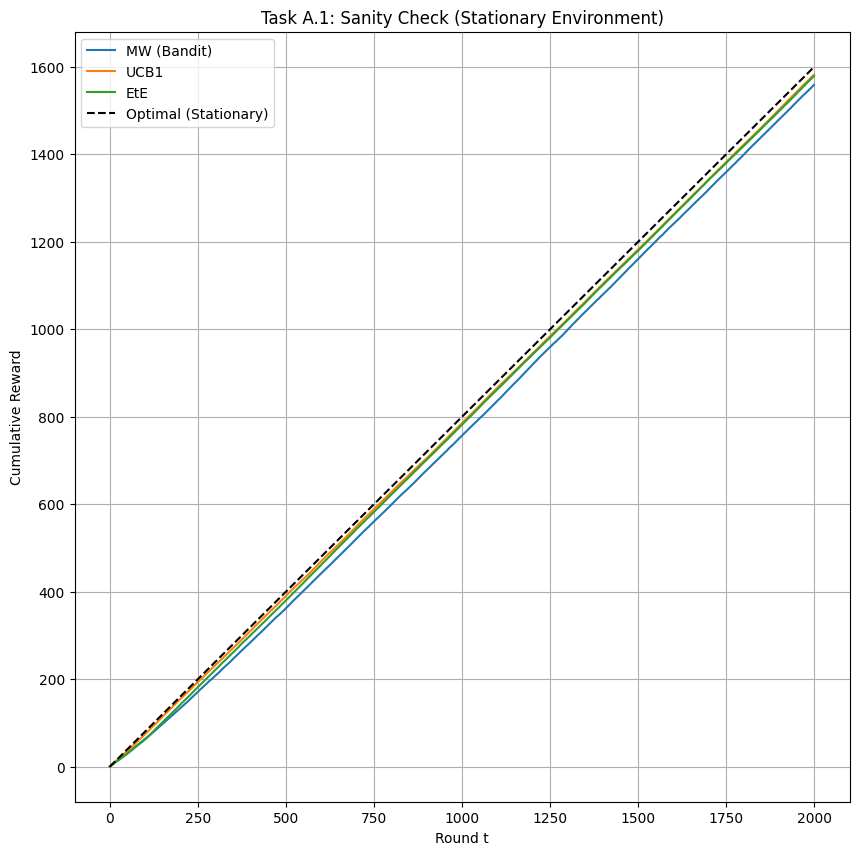

Final Rewards (Mean ± Std):
MW:  1558.30 ± 12.92
UCB: 1581.60 ± 18.26


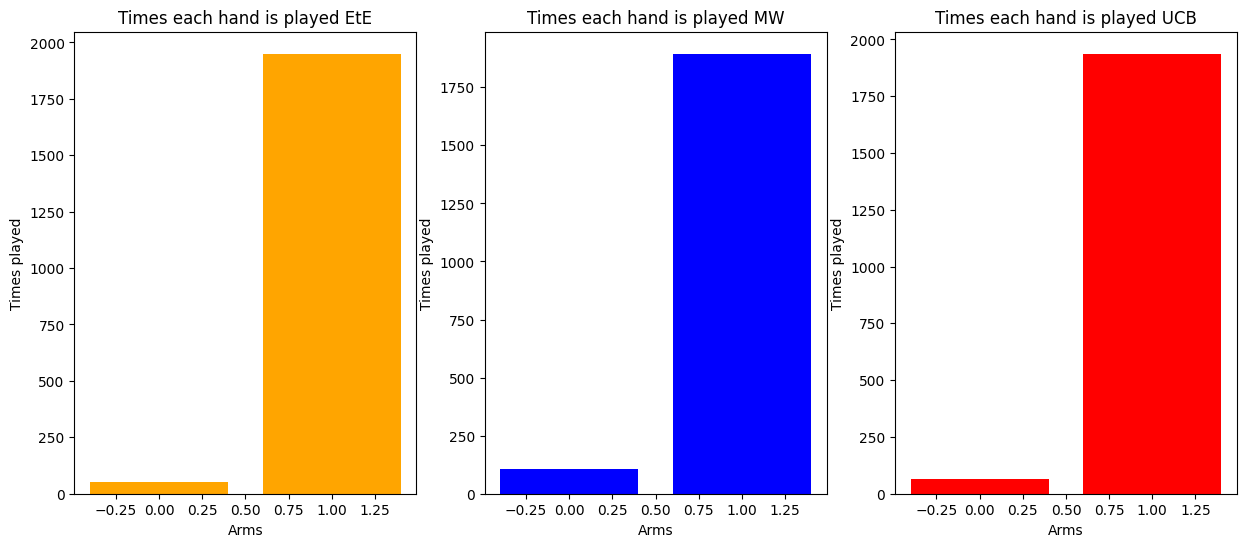

In [6]:
#Sanity check variables:
T = 2000

p_l = [0.4,0.8]
p_h = [0.4,0.8]

t_l = [50,30]
t_h = [25, 50]

initial_states = ["Low", "High"]



mc_runs = 20

rewards_mw = np.zeros((mc_runs,T))
rewards_ucb = np.zeros((mc_runs,T))
rewards_ete = np.zeros((mc_runs,T))

arms_selected_mw = np.zeros((mc_runs, n_arms))
arms_selected_ucb = np.zeros((mc_runs, n_arms))
arms_selected_ete = np.zeros((mc_runs, n_arms))

for m in range(mc_runs):
  np.random.seed(m)
  env_mw = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ete = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ucb = Environment(p_l, p_h, t_l, t_h, initial_states)

  rewards_ete[m,:], arms_selected_ete[m,:] = run_ExploreThenExploit(T, env_ete)
  rewards_ucb[m,:], arms_selected_ucb[m,:] = run_UCB(T, env_ucb)
  rewards_mw[m,:], arms_selected_mw[m,:] = run_MWbandit(T, env_mw)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ucb = np.mean(rewards_ucb, axis=0)
mean_ete = np.mean(rewards_ete, axis=0)

mean_selection_mw = np.mean(arms_selected_mw, axis=0)
mean_selection_ucb = np.mean(arms_selected_ucb, axis=0)
mean_selection_ete = np.mean(arms_selected_ete, axis=0)

plt.figure(figsize=(10, 10))
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ucb, label='UCB1')
plt.plot(mean_ete, label='EtE')
plt.plot([0, T], [0, 0.8*T], 'k--', label='Optimal (Stationary)')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task A.1: Sanity Check (Stationary Environment)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Final Values (Mean ± Std) [cite: 3, 42]
print(f"Final Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")
print(f"UCB: {np.mean(rewards_ucb[:,-1]):.2f} ± {np.std(rewards_ucb[:,-1]):.2f}")

plt.figure(figsize=(15,6))
arm_indices = np.arange(n_arms)
plt.subplot(1,3,1)
plt.bar(arm_indices, mean_selection_ete, color = 'orange')
plt.title("Times each hand is played EtE")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.subplot(1,3,2)
plt.bar(arm_indices, mean_selection_mw, color = 'blue', label = 'Multiplicative Weights')
plt.title("Times each hand is played MW")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.subplot(1,3,3)
plt.bar(arm_indices, mean_selection_ucb, color = 'red', label = 'UCB')
plt.title("Times each hand is played UCB")
plt.xlabel("Arms")
plt.ylabel("Times played")
plt.show()

# Task A.2

We can notice that an environment is easily exploitable especially vs an explore then exploit algorithm. We should make the time where an arm seems good be the same as N and then for the rest time just change it to be the worse arm so if we suppose arm 1 is the best we put t_h[arm0] = N and t_l[arm1] = N while the opposite are: t_l[arm0] >>>N and t_h[arm1]>>>N so if we make the environment as such the algorithm is confused and plays the wrong hand while the MW algorithm doesnt get confused since it's created to play in such an environment.

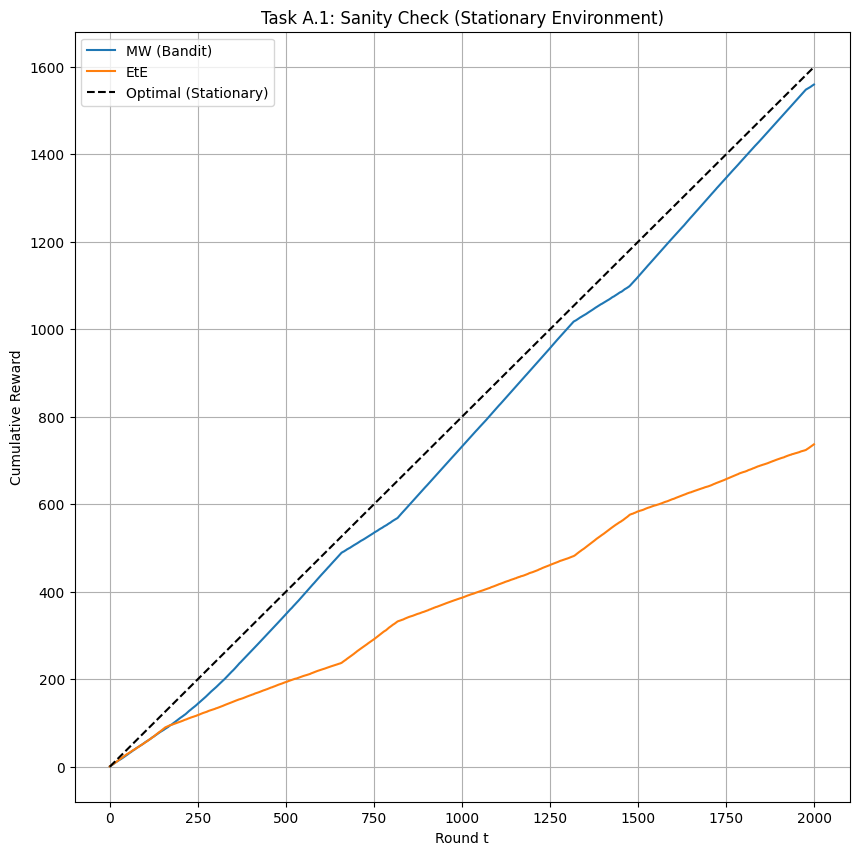

Final Rewards (Mean ± Std):
MW:  1559.30 ± 27.13


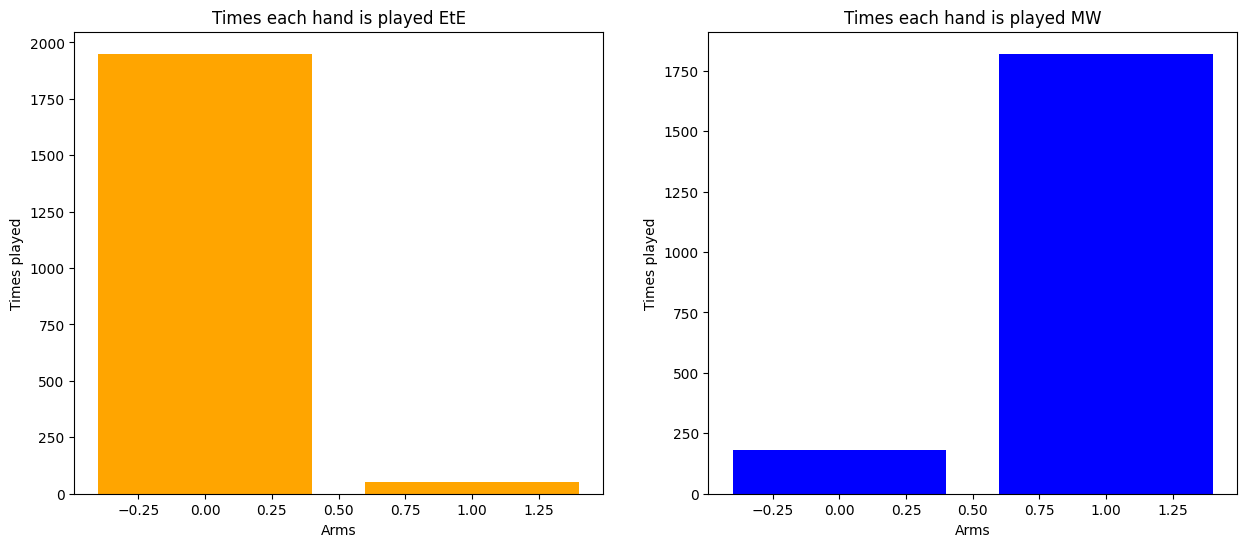

In [7]:
T = 2000

p_l = [0.3,0.5]
p_h = [0.6,0.9]

N = np.power(T,2/3)

t_l = [500,N]
t_h = [N, 500]

initial_states = ["High", "Low"]



mc_runs = 20

rewards_mw = np.zeros((mc_runs,T))
rewards_ete = np.zeros((mc_runs,T))

arms_selected_mw = np.zeros((mc_runs, n_arms))
arms_selected_ete = np.zeros((mc_runs, n_arms))

for m in range(mc_runs):
  np.random.seed(m)
  env_mw = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ete = Environment(p_l, p_h, t_l, t_h, initial_states)

  rewards_ete[m,:], arms_selected_ete[m,:] = run_ExploreThenExploit(T, env_ete)
  rewards_mw[m,:], arms_selected_mw[m,:] = run_MWbandit(T, env_mw)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ete = np.mean(rewards_ete, axis=0)

mean_selection_mw = np.mean(arms_selected_mw, axis=0)
mean_selection_ete = np.mean(arms_selected_ete, axis=0)

plt.figure(figsize=(10, 10))
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ete, label='EtE')
plt.plot([0, T], [0, 0.8*T], 'k--', label='Optimal (Stationary)')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task A.1: Sanity Check (Stationary Environment)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Final Values (Mean ± Std) [cite: 3, 42]
print(f"Final Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")


plt.figure(figsize=(15,6))
arm_indices = np.arange(n_arms)
plt.subplot(1,2,1)
plt.bar(arm_indices, mean_selection_ete, color = 'orange')
plt.title("Times each hand is played EtE")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.subplot(1,2,2)
plt.bar(arm_indices, mean_selection_mw, color = 'blue', label = 'Multiplicative Weights')
plt.title("Times each hand is played MW")
plt.xlabel("Arms")
plt.ylabel("Times played")

plt.show()

# Part B

In [8]:
SEED = 52
np.random.seed(SEED)
K=20 #Num of arms

#Learner arms
p = np.sort(np.random.uniform(0, 5, K))

In [10]:
#Returns true if the learner is chosen false if the competitor
def customer_Choice(beta, pt, qt):

  pr_l= 1.0/(1.0+np.exp(beta*(pt-qt)))
  return np.random.rand() < pr_l

### 1. The Customer Choice Model
According to the problem description, the probability that a customer chooses the learner is given by the logistic function:

$$P(\text{learner}) = \frac{1}{1 + \exp(\beta(p_t - q_t))}$$

Where:
* $p_t$ is the price posted by the learner.
* $q_t$ is the price posted by the competitor.
* $\beta > 0$ is the price sensitivity parameter.

Since the customer must choose one of the two sellers, the probability they choose the competitor is:

$$P(\text{competitor}) = 1 - P(\text{learner}) = 1 - \frac{1}{1 + \exp(\beta(p_t - q_t))}$$

By multiplying the numerator and denominator by $\exp(-\beta(p_t - q_t))$, this algebraically simplifies to:

$$P(\text{competitor}) = \frac{1}{1 + \exp(-\beta(p_t - q_t))}$$

---

### 2. Competitor Expected Reward
If the competitor is chosen, they receive a reward equal to their posted price $q_t$. If they are not chosen, they receive $0$. Therefore, the expected reward for the competitor for a specific pair of prices $(p_t, q_t)$ is:

$$\mathbb{E}[R_c(q_t \mid p_t)] = q_t \cdot P(\text{competitor}) = \frac{q_t}{1 + \exp(-\beta(p_t - q_t))}$$

---

### 3. Derivation Against UCB (Deterministic Learner)
UCB is a deterministic algorithm. Therefore, the myopic competitor knows exactly which price $p_t$ the learner will post in round $t$.

To maximize their immediate expected reward, the competitor must solve the following optimization problem:

$$q_t^* = \arg\max_{q_t \in \mathbb{R}_+} \left[ \frac{q_t}{1 + \exp(-\beta(p_t - q_t))} \right]$$

**Note on solvability:** If we take the derivative of this expected reward with respect to $q_t$ and set it to $0$, we obtain a transcendental equation that has no simple algebraic (closed-form) solution. Because of this, the optimal price $q_t^*$ must be found using **numerical optimization** (e.g., `scipy.optimize.minimize_scalar`).

---

### 4. Derivation Against MW (Randomized Learner)
Multiplicative Weights (MW) is a randomized algorithm. The competitor does not know the exact price the learner will post, but they know the learner's probability distribution $\pi_t$ over the discrete set of $K$ prices, $\mathcal{P} = \{p^{(1)}, p^{(2)}, \dots, p^{(K)}\}$.

The competitor's expected reward is the sum of the expected rewards against each possible learner price, weighted by the probability $\pi_t(k)$ that the learner actually selects that price:

$$\mathbb{E}[R_c(q_t)] = \sum_{k=1}^K \pi_t(k) \left[ \frac{q_t}{1 + \exp(-\beta(p^{(k)} - q_t))} \right]$$

To find the myopic best-response, the competitor maximizes this aggregate expected reward:

$$q_t^* = \arg\max_{q_t \in \mathbb{R}_+} \sum_{k=1}^K \pi_t(k) \left[ \frac{q_t}{1 + \exp(-\beta(p^{(k)} - q_t))} \right]$$

As with the UCB case, this objective function is solved programmatically via numerical optimization at each round $t$.

In [12]:
def expected_reward(qt, beta, ucb_choice):
    pr_c = 1.0/(1.0+np.exp(-beta*(ucb_choice-qt)))
    return qt*pr_c

def competitor_choice_UCB(beta, ucb_choice):
#There is only a minimize function so we need to minimize -reward to find the maximum
  def objective(qt):
    return -expected_reward(qt, beta, ucb_choice)

  optimal_price = scipy.optimize.minimize_scalar(objective,bounds = [0.01, 10])
  return optimal_price.x


### 1. The Customer Choice Model
The probability that a customer chooses the learner is given by the logistic function:

$$P(\text{learner}) = \frac{1}{1 + \exp(\beta(p_t - q_t))}$$

Since the customer must choose one of the two sellers, the probability they choose the competitor is:

$$P(\text{competitor}) = 1 - \frac{1}{1 + \exp(\beta(p_t - q_t))}$$

By multiplying the numerator and denominator by $\exp(-\beta(p_t - q_t))$, this algebraically simplifies to:

$$P(\text{competitor}) = \frac{1}{1 + \exp(-\beta(p_t - q_t))}$$

---

### 2. Competitor's Expected Reward against a Known Price
If the competitor is chosen, they receive a reward equal to their posted price $q_t$. If they lose, they receive $0$. The expected reward against a specific learner price $p_t$ is:

$$\mathbb{E}[R_c(q_t \mid p_t)] = q_t \cdot P(\text{competitor}) = \frac{q_t}{1 + \exp(-\beta(p_t - q_t))}$$

---

### 3. Best Response against UCB (Deterministic Learner)
UCB is deterministic, meaning the competitor knows exactly which price $p_t$ the learner will post. To maximize immediate expected reward, the competitor solves:

$$q_t^* = \arg\max_{q_t \in \mathbb{R}_+} \left[ \frac{q_t}{1 + \exp(-\beta(p_t - q_t))} \right]$$

*Because setting the derivative to zero yields a transcendental equation with no closed-form solution, this maximum must be found using numerical optimization.*

---

### 4. Best Response against MW (Randomized Learner)
Multiplicative Weights (MW) maintains a probability distribution $\pi_t$ over a discrete set of $K$ prices, $\mathcal{P} = \{p^{(1)}, \dots, p^{(K)}\}$. The probability of the learner choosing price $p^{(k)}$ is $\pi_t(k)$.

By the Law of Total Expectation, the competitor's total expected reward is the sum of the expected rewards against each possible price, weighted by their probabilities:

$$\mathbb{E}[R_c(q_t)] = \sum_{k=1}^K \pi_t(k) \left( \frac{q_t}{1 + \exp(-\beta(p^{(k)} - q_t))} \right)$$

To find the myopic best-response, the competitor maximizes this aggregate expected reward:

$$q_t^* = \arg\max_{q_t \in \mathbb{R}_+} \sum_{k=1}^K \pi_t(k) \left( \frac{q_t}{1 + \exp(-\beta(p^{(k)} - q_t))} \right)$$

Because numerical solvers (like `scipy.optimize.minimize_scalar`) find minimums, we programmatically find the maximum profit by minimizing the **negative** expected reward:

$$q_t^* = \arg\min_{q_t \in \mathbb{R}_+} \left[ - \sum_{k=1}^K \pi_t(k) \left( \frac{q_t}{1 + \exp(-\beta(p^{(k)} - q_t))} \right) \right]$$

In [ ]:
def competitor_choice_MW(beta, MW_probabilities, arms):
  def objective(qt):
    expected_reward = 0

    for (pr, arm) in zip(MW_probabilities, arms):
      expected_reward += pr * expected_reward(qt, beta, MW_probabilities)
    return -expected_reward

  optimal_price = scipy.optimize.minimize_scalar(objective,bounds = [0.01, 10])
  return optimal_price.x

In [ ]:
def run_UCB_learner(T, beta):
  reward = np.zeros(T)
  arm_selected = np.zeros(K)

  Xin = np.zeros(K)
  rin = np.zeros(K)
  mu_hat = np.zeros(K)

  for t in range(T):
    if t<K:
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    qt = competitor_choice_UCB(beta, p[arm_i])
    if(customer_Choice(beta, p[arm_i], qt)):
      r = p[arm_i]
    else:
      r = 0
    #What our algorithm has access to:
    rin[arm_i] += r
    Xin[arm_i] += 1
    mu_hat[arm_i] = rin[arm_i] / Xin[arm_i]

    arm_selected[arm_i] += 1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward,arm_selected

In [ ]:
def run_MW_learner(T, beta):
  weights = np.ones(K)
  ita = np.sqrt(np.log(K)/T)

  reward = np.zeros(T)
  arm_selected = np.zeros(K)

  for t in range(T):

    weights_sum = np.sum(weights)
    pi = weights / weights_sum

    arm_i = np.random.choice(K,p = pi)

    qt = competitor_choice_MW(beta, pi, p)
    if(customer_Choice(beta, p[arm_i], qt)):
      r = p[arm_i]
    else:
      r = 0

    l = 1 - r

    est_loss = l / pi[arm_i]

    weights[arm_i] *= np.exp(-ita * est_loss)

    arm_selected[arm_i] +=1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward , arm_selected